In [5]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt
import fastf1
from fastf1 import plotting


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

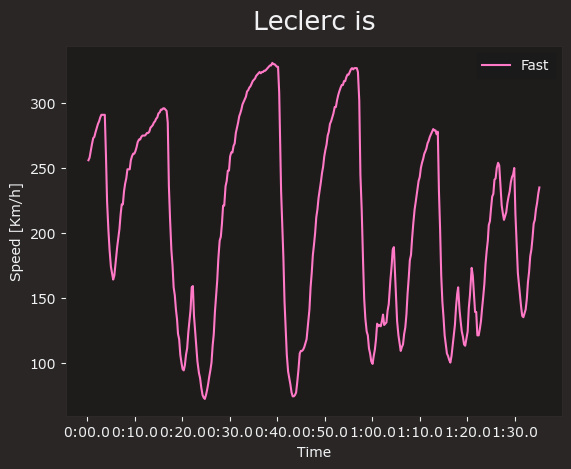

In [8]:
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

session = fastf1.get_session(2019, 'Abu Dhabi', 'Q')

session.load()
fast_leclerc = session.laps.pick_drivers('LEC').pick_fastest()
lec_car_data = fast_leclerc.get_car_data()
t = lec_car_data['Time']
vCar = lec_car_data['Speed']

# The rest is just plotting
fig, ax = plt.subplots()
ax.plot(t, vCar, label='Fast')
ax.set_xlabel('Time')
ax.set_ylabel('Speed [Km/h]')
ax.set_title('Leclerc is')
ax.legend()
plt.show()

core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '77', '33', '16', '5', '23', '4', '3', '55', '27', '11', '10', '18', '26', '20', '8', '99', '7', '63', '88']


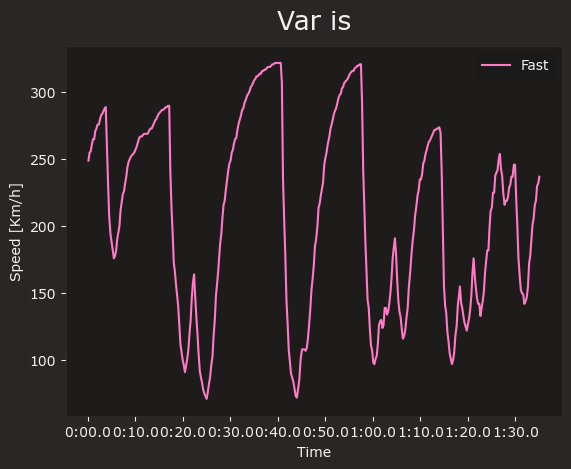

In [10]:
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

session = fastf1.get_session(2019, 'Abu Dhabi', 'Q')

session.load()
fast_var = session.laps.pick_drivers('VER').pick_fastest()
var_car_data = fast_var.get_car_data()
t = var_car_data['Time']
vCar = var_car_data['Speed']

# The rest is just plotting
fig, ax = plt.subplots()
ax.plot(t, vCar, label='Fast')
ax.set_xlabel('Time')
ax.set_ylabel('Speed [Km/h]')
ax.set_title('Var is')
ax.legend()
plt.show()

In [7]:
import os
import fastf1
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Enable FastF1 caching
cache_dir = "f1_cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache("f1_cache")


# Load 2024 Chinese GP race session
session_2024 = fastf1.get_session(2024, "China", "R")
session_2024.load()

# Extract lap and sector times
laps_2024 = session_2024.laps[["Driver", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]].copy()
laps_2024.dropna(inplace=True)

# Convert times to seconds
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    laps_2024[f"{col} (s)"] = laps_2024[col].dt.total_seconds()

# Group by driver to get average sector times per driver
sector_times_2024 = laps_2024.groupby("Driver")[["Sector1Time (s)", "Sector2Time (s)", "Sector3Time (s)"]].mean().reset_index()

# 2025 Qualifying Data Chinese GP
qualifying_2025 = pd.DataFrame({
    "Driver": ["Oscar Piastri", "George Russell", "Lando Norris", "Max Verstappen", "Lewis Hamilton",
               "Charles Leclerc", "Isack Hadjar", "Andrea Kimi Antonelli", "Yuki Tsunoda", "Alexander Albon",
               "Esteban Ocon", "Nico Hülkenberg", "Fernando Alonso", "Lance Stroll", "Carlos Sainz Jr.",
               "Pierre Gasly", "Oliver Bearman", "Jack Doohan", "Gabriel Bortoleto", "Liam Lawson"],
    "QualifyingTime (s)": [90.641, 90.723, 90.793, 90.817, 90.927,
                           91.021, 91.079, 91.103, 91.638, 91.706,
                           91.625, 91.632, 91.688, 91.773, 91.840,
                           91.992, 92.018, 92.092, 92.141, 92.174]
})

# Map full names to FastF1 3-letter codes
driver_mapping = {
    "Oscar Piastri": "PIA", "George Russell": "RUS", "Lando Norris": "NOR", "Max Verstappen": "VER",
    "Lewis Hamilton": "HAM", "Charles Leclerc": "LEC", "Isack Hadjar": "HAD", "Andrea Kimi Antonelli": "ANT",
    "Yuki Tsunoda": "TSU", "Alexander Albon": "ALB", "Esteban Ocon": "OCO", "Nico Hülkenberg": "HUL",
    "Fernando Alonso": "ALO", "Lance Stroll": "STR", "Carlos Sainz Jr.": "SAI", "Pierre Gasly": "GAS",
    "Oliver Bearman": "BEA", "Jack Doohan": "DOO", "Gabriel Bortoleto": "BOR", "Liam Lawson": "LAW"
}

qualifying_2025["DriverCode"] = qualifying_2025["Driver"].map(driver_mapping)

# Merge qualifying data with sector times
merged_data = qualifying_2025.merge(sector_times_2024, left_on="DriverCode", right_on="Driver", how="left")

# Define feature set (Qualifying + Sector Times)
X = merged_data[["QualifyingTime (s)", "Sector1Time (s)", "Sector2Time (s)", "Sector3Time (s)"]].fillna(0)
y = laps_2024.groupby("Driver")["LapTime (s)"].mean().reset_index()["LapTime (s)"]

# Train Gradient Boosting Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=38)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=38)
model.fit(X_train, y_train)

# Predict race times using 2025 qualifying and sector data
predicted_race_times = model.predict(X)
qualifying_2025["PredictedRaceTime (s)"] = predicted_race_times

# Rank drivers by predicted race time
qualifying_2025 = qualifying_2025.sort_values(by="PredictedRaceTime (s)")

# Print final predictions
print("\n🏁 Predicted 2025 Chinese GP Winner with New Drivers and Sector Times 🏁\n")
print(qualifying_2025[["Driver", "PredictedRaceTime (s)"]])

# Evaluate Model
y_pred = model.predict(X_test)
print(f"\n🔍 Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:08.313000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '11', '16', '55', '63', '14', '81', '44', '27', '31', '23', '10', '24', '18', '20', '2', '3', '22', '77']



🏁 Predicted 2025 Chinese GP Winner with New Drivers and Sector Times 🏁

                   Driver  PredictedRaceTime (s)
2            Lando Norris             103.911242
16         Oliver Bearman             105.768026
10           Esteban Ocon             105.937552
6            Isack Hadjar             106.014323
8            Yuki Tsunoda             107.250668
1          George Russell             107.378067
5         Charles Leclerc             107.433970
14       Carlos Sainz Jr.             107.987549
13           Lance Stroll             108.029351
11        Nico Hülkenberg             108.380663
7   Andrea Kimi Antonelli             108.485977
18      Gabriel Bortoleto             108.539843
19            Liam Lawson             108.539843
4          Lewis Hamilton             109.072694
9         Alexander Albon             109.209534
0           Oscar Piastri             109.248207
3          Max Verstappen             109.305052
15           Pierre Gasly             109.554